In [2]:
import sys 
sys.path.append("/home/feity/cryoem/")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import torch
import importlib 
import modules
import data

import postprocess 

import pickle
importlib.reload(data)

/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'data' from '/home/feity/cryoem/data.py'>

### test mito


In [39]:
gth = utils.readTomogram("/data/transformer_project/transforemer_model/train_data/training/compare/sllt0039_2d.mrc")
predicted = utils.readTomogram("/data/transformer_project/transforemer_model/train_data/training/deepict/mito_fold1_out/sllt0039_pred.mrc")

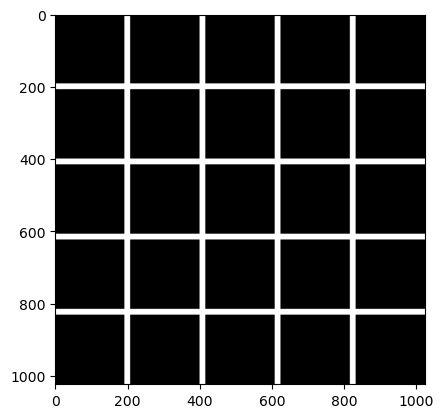

In [40]:
plt.imshow(predicted[250], cmap="gray")

In [2]:
with open("/home/feity/cryoem/temp/hsp60_centers.pkl", "rb") as f:
    hsp60_centers = pickle.load(f)
# hsp60_centers.keys()
labels = hsp60_centers["24092001"]
labels.shape
df = pd.read_csv("/home/feity/cryoem/temp/hsp60_final_results.csv")
df = df[df["tomogram"] == 24092001]
predict_center = df[["z", "y", "x"]].values
score = df["score"].values 
idx = np.argsort(-score)
predict_center = predict_center[np.argsort(-score)]
score = score[idx]
predict_center = predict_center[idx]

# 按照数量
score = score[:500]
predict_center = predict_center[:500]
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)

# 按照分数
predict_center = predict_center[score > 4.0]
score = score[score > 4.0]
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
t, len(score)

({'auroc': 0.6855775024018498,
  'aupr': 0.6290715942058392,
  'aupr2': 0.6325288007646735,
  'cnts': 217},
 500)

In [3]:
df = pd.read_csv("/home/feity/cryoem/temp/hsp60_final_results.csv")
df = df[df["tomogram"] == 24092001]
df.head()

,Unnamed: 0,z,y,x,score,tomogram
0,0,178.5,199.130079,312.642185,9.466115,24092001
1,1,202.5,105.626819,399.520618,9.445540,24092001
2,2,186.5,107.411128,407.439210,9.426011,24092001
3,3,155.1,62.179599,397.171260,9.424313,24092001
4,4,204.5,222.821178,496.093943,9.412305,24092001


In [11]:
with open("/home/feity/cryoem/temp/hsp60_centers.pkl", "rb") as f:
    hsp60_centers = pickle.load(f)
need = ["24092001", "24092002", "24092018", "24092024", "24092028", "24092031"]
dfs = []
for i in need:
    print(i)
    df = pd.read_csv(f"/home/feity/cryoem/temp/hsp60/{i}/df.csv")
    df2 = pd.read_csv(f"/home/feity/cryoem/temp/hsp60/{i}/labels.csv")
    df2 = df2.set_index("sample")
    mapping = dict(df2["label"]) 
    # df["if_pos"] = df["label_id"].apply(lambda x: mapping.get(x, "negative"))
    # df = df[df["if_pos"]!="negative"]
    score, predict_center, ids = postprocess.getPredictionCenters(df, "hsp60", image_size=1024, top_n=10)
    idx = np.argsort(-score)
    # idx = idx[:500]
    score = score[idx]
    predict_center = predict_center[idx]
    ids = ids[idx]
    labels = hsp60_centers[i]
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
    # roc, cnt, cnt/len(centers), cnt/len(idx), len(score), len(centers)
    print(t)
    print("final score:", t["aupr2"]*t["cnts"]/len(labels))
    df = pd.DataFrame(predict_center, columns=["z", "y", "x"]) 
    df["score"] = score
    df["tomogram"] = i 
    dfs.append(df)
    # df.head()
df = pd.concat(dfs, ignore_index=True)
df.head()

24092001
{'auroc': 0.8227491445901274, 'aupr': 0.5583379881386725, 'aupr2': 0.5613578386038058, 'cnts': 263}
final score: 0.4747174004913214
24092002
{'auroc': 0.789974608177918, 'aupr': 0.3591982740029583, 'aupr2': 0.36346826938685295, 'cnts': 135}
final score: 0.2955916648628021
24092018
{'auroc': 0.5999458954306232, 'aupr': 0.20602568089975523, 'aupr2': 0.21292314915736385, 'cnts': 81}
final score: 0.11055625052401584
24092024
{'auroc': 0.8006762614877753, 'aupr': 0.29833212087480354, 'aupr2': 0.3030704421773758, 'cnts': 146}
final score: 0.24999030823670546
24092028
{'auroc': 0.814528653517627, 'aupr': 0.27393437702607515, 'aupr2': 0.28825135694104, 'cnts': 47}
final score: 0.24192524600408713
24092031
{'auroc': 0.8441164241164242, 'aupr': 0.4459782751340021, 'aupr2': 0.44964193621239834, 'cnts': 125}
final score: 0.39581156356725206


,z,y,x,score,tomogram
0,178.5,199.130079,312.642185,9.466115,24092001
1,202.5,105.626819,399.520618,9.445540,24092001
2,186.5,107.411128,407.439210,9.426011,24092001
3,155.1,62.179599,397.171260,9.424313,24092001
4,204.5,222.821178,496.093943,9.412305,24092001


In [23]:
import numpy as np

def cube_sum_around_point(arr, point, cube_size=15):
    """
    arr: 3D NumPy array
    point: tuple or list (x, y, z)
    cube_size: cube dimension (default 15)
    """
    x, y, z = map(int, point)
    half = cube_size // 2  # e.g. 7 for 15x15x15 cube

    # Compute start and end indices for each dimension
    x1, x2 = x - half, x + half + 1
    y1, y2 = y - half, y + half + 1
    z1, z2 = z - half, z + half + 1

    # Calculate padding if the cube goes outside
    pad_x1, pad_x2 = max(0, -x1), max(0, x2 - arr.shape[0])
    pad_y1, pad_y2 = max(0, -y1), max(0, y2 - arr.shape[1])
    pad_z1, pad_z2 = max(0, -z1), max(0, z2 - arr.shape[2])

    # Clip coordinates to array boundaries
    x1_clip, x2_clip = max(0, x1), min(arr.shape[0], x2)
    y1_clip, y2_clip = max(0, y1), min(arr.shape[1], y2)
    z1_clip, z2_clip = max(0, z1), min(arr.shape[2], z2)

    # Extract the valid sub‑cube
    subcube = arr[x1_clip:x2_clip, y1_clip:y2_clip, z1_clip:z2_clip]

    # Pad with zeros if necessary
    if any((pad_x1, pad_x2, pad_y1, pad_y2, pad_z1, pad_z2)):
        subcube = np.pad(subcube,
                         ((pad_x1, pad_x2),
                          (pad_y1, pad_y2),
                          (pad_z1, pad_z2)),
                         mode='constant', constant_values=0)

    # Return the sum of this cube
    return np.sum(subcube)


In [35]:
with open("/home/feity/cryoem/temp/hsp60_centers.pkl", "rb") as f:
    hsp60_centers = pickle.load(f)
labels = hsp60_centers["24092001"]

In [37]:
predict = pd.read_csv("/data/transformer_project/transforemer_model/train_data/training/deepict/hsp60_fold11_out/predictions/hsp60_model_fold11/24092001/hsp60/motl_5554.csv", header=None)
predict = predict[predict[0] < 1000]
predict_mrc = utils.readTomogram("/data/transformer_project/transforemer_model/train_data/training/deepict/hsp60_fold11_out/predictions/hsp60_model_fold11/24092001/hsp60/probability_map.mrc") 
predict_center = predict[[9, 8, 7]].values
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
# predict_center[:, 1] = 1024 - predict_center[:, 1]
# predict_center[:, 2] = 1024 - predict_center[:, 2]
# score = -predict[3].values
score = np.array([cube_sum_around_point(predict_mrc, point, cube_size=15) for point in predict_center])
t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
print(t)
print("final score:", t["aupr2"]*t["cnts"]/len(labels))

{'auroc': 0.7786631642789235, 'aupr': 0.06428174180733097, 'aupr2': 0.06645390919721798, 'cnts': 141}
final score: 0.030128621211600433


In [ ]:
predict

In [20]:
import os 
for i in [22, 33, 44, 55, 66]:
    os.system(f"rm -rf /data/transformer_project/transforemer_model/train_data/training/deepict/hsp60_fold{i}_out/predictions/hsp60_model_fold{i}/")

In [5]:
with open("/home/feity/cryoem/temp/ribo_centers_new.pkl", "rb") as f:
    ribo_centers = pickle.load(f)
labels = ribo_centers["24092002"]

In [6]:
# predict = pd.read_csv("/data/transformer_project/transforemer_model/train_data/training/deepict/ribosome_fold2_out/predictions/ribosome_model_fold2/24092016/ribosome/motl_1241.csv", header=None)
predict = pd.read_csv("/data/transformer_project/transforemer_model/train_data/training/deepict/ribosome_fold2_out/predictions/ribosome_model_fold2/24092002/ribosome/motl_708.csv", header=None)
# predict = predict[predict[0] < 20000]
# predict_center = predict_center[predict_center[0] < 20000]
predict_center = predict[[9, 8, 7]].values
predict_center = np.array(predict_center, dtype=np.float32)
# predict_center[:, 1] = 1024.0 - predict_center[:, 1]
# predict_center[:, 2] = 1024.0 - predict_center[:, 2]
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
score = -predict[3].values
t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
print(t)
print("final score:", t["aupr2"]*t["cnts"]/len(labels))

{'auroc': 0.6706614021428837, 'aupr': 0.45102285112331275, 'aupr2': 0.4546643770805685, 'cnts': 222}
final score: 0.2601430198759954


In [32]:
predict_center[0]

array([  22,  845, 1010])

In [5]:
predict.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,624,20,129,1,0,0,0,20,129,41,0,0,0,0,0,0,0,0,0,1
1,198,94,789,2,0,0,0,94,789,52,0,0,0,0,0,0,0,0,0,1
2,4627,71,808,3,0,0,0,71,808,72,0,0,0,0,0,0,0,0,0,1
3,250,84,996,4,0,0,0,84,996,65,0,0,0,0,0,0,0,0,0,1
4,3300,20,354,5,0,0,0,20,354,77,0,0,0,0,0,0,0,0,0,1


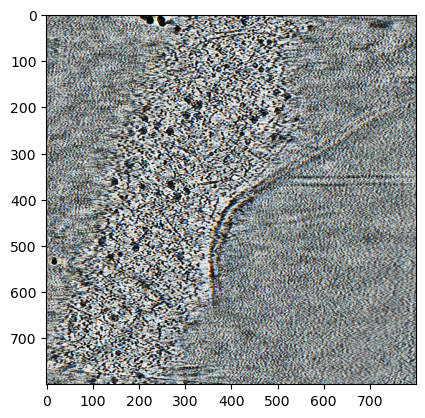

244.47832990846254 323.4254623575565 271.15813562488324
241.15679312278078 420.4283311530555 232.68734815922258
244.78941462502337 415.2290069197681 272.0742472414438
242.6137254901961 820.0254901960784 259.2207282913165
241.9168770453483 205.213090229079 473.7015427769986
244.3074696545285 218.8248366013072 641.7856209150327
246.34673882616403 281.7922926192031 422.85956890920966
243.4959341994579 242.3655481820731 480.2549771006636
245.3357888847445 584.0737597911227 316.67801193584484
245.67990305741984 495.23424683072335 314.4601043997017
248.9187978346089 280.6498973305955 387.07168191151766
250.51807228915663 291.17997571682076 577.2217241057252
245.20043523078684 231.2360554346581 396.0875042950407
249.0784203630919 462.67958075987275 188.54089462848586
247.89494308639672 669.81330472103 372.4648255271506
249.42146670413038 227.0152664606163 668.5219630982485
250.31735351836278 252.77618914120177 420.7232968881413
248.43989147721956 646.8821218074656 248.6524464402657
251.191632

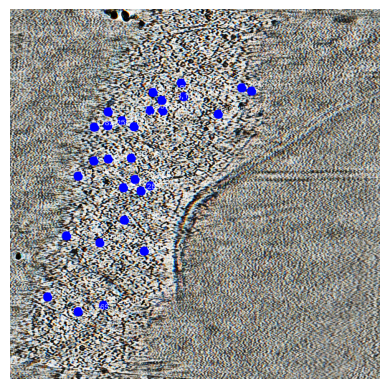

244.0 254.0 267.0
242.0 820.0 258.0
242.0 245.0 479.0
251.0 253.0 411.0
244.0 177.0 619.0
243.0 206.0 471.0
244.0 584.0 317.0
250.0 279.0 386.0
249.0 322.0 268.0
247.0 670.0 371.0
246.0 939.0 22.0
248.0 463.0 190.0
248.0 24.0 548.0
247.0 216.0 638.0
251.0 307.0 308.0
245.0 74.0 382.0
255.0 840.0 189.0
251.0 329.0 236.0
241.0 342.0 652.0
259.0 491.0 581.0
249.0 998.0 256.0
254.0 227.0 668.0
259.0 799.0 102.0
252.0 499.0 574.0
253.0 652.0 350.0
255.0 435.0 197.0
256.0 594.0 277.0
256.0 33.0 365.0
252.0 845.0 71.0


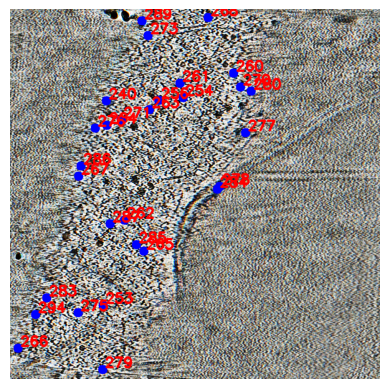

In [27]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

take = 250
img = dataset.__getitem__(pos=take)["pixel_values"]
img = img.numpy().transpose(1, 2, 0)
img = (img - img.min()) / (img.max() - img.min()) * 255
img = img.astype(np.uint8)
img = img.copy()
plt.imshow(img)
plt.show()
plt.close()

# Example: your image array of shape (3, 800, 800)
# image_array = your_image_array
# Simulating a random image here for demonstration
# image_array = np.random.randint(0, 255, (3, 800, 800), dtype=np.uint8)

# Transpose from (C, H, W) -> (H, W, C)
# image_array = np.transpose(image_array, (1, 2, 0)).copy()

image_array = img.copy()

# Example label points
# points = [(100, 150), (250, 400), (500, 600)]
points = []
for z, y, x in labels:
    if abs(z - take) < 10:
        print(z, y, x)
        points.append((int(x/1024*800), int(y/1024*800)))
# Draw points
for (x, y) in points:
    cv2.circle(image_array, (x, y), 10, (255, 0, 0), -1)  # Blue points
    cv2.putText(image_array, f"({x},{y})", (x+5, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Show using matplotlib (avoids CV2 window issues)
plt.imshow(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

image_array = img.copy()

predict_center = predict[[9, 8, 7]].values
predict_center = np.array(predict_center, dtype=np.float32)
predict_center[:, 1] = predict_center[:, 1]
predict_center[:, 2] = predict_center[:, 2]
# Example label points
# points = [(100, 150), (250, 400), (500, 600)]
points = []
for i, (z, y, x) in enumerate(predict_center):
    if abs(z - take) < 10:
        print(z, y, x)
        points.append((int(x/1024*800), int(y/1024*800)))
        x = int(x/1024*800) 
        y = int(y/1024*800)
# Draw points
# for i, (x, y) in enumerate(points):
        cv2.circle(image_array, (x, y), 10, (255, 0, 0), -1)  # Blue points
        cv2.putText(image_array, str(i), (x+5, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)
    
# for (x, y) in points:
    # cv2.circle(image_array, (x, y), 10, (255, 0, 0), -1)  # Blue points
    # cv2.putText(image_array, f"({x},{y})", (x+5, y-5),
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Show using matplotlib (avoids CV2 window issues)
plt.imshow(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [74]:
df.to_csv("/home/feity/cryoem/temp/hsp60_final_results.csv")

In [39]:
with open("/home/feity/cryoem/temp/results/hsp60_24092001.pkl", "rb") as f:
    res = pickle.load(f) 
df = res["df"]

In [23]:
df = pd.read_csv("/home/feity/cryoem/temp/hsp60/24092031/df.csv")
df2 = pd.read_csv("/home/feity/cryoem/temp/hsp60/24092031/labels.csv")
df2 = df2.set_index("sample")
mapping = dict(df2["label"])
df["if_pos"] = df["label_id"].apply(lambda x: mapping.get(x, "negative"))
df.head()

,Unnamed: 0,z,x,y,w,h,hsp60,None,max,largest,unlabeled,label,label_id,class_value,if_pos
0,0,5,0.013847,0.045772,0.014492,0.014234,0.663481,0.336519,0.663481,hsp60,False,hsp60,0,0.663481,negative
1,1,6,0.014547,0.045992,0.014453,0.014053,0.662955,0.337045,0.662955,hsp60,False,hsp60,0,0.662955,negative
2,2,7,0.015039,0.044993,0.015600,0.015753,0.663309,0.336691,0.663309,hsp60,False,hsp60,0,0.663309,negative
3,3,8,0.009769,0.043484,0.013790,0.015820,0.661125,0.338875,0.661125,hsp60,False,hsp60,0,0.661125,negative
4,4,9,0.009272,0.050488,0.014419,0.016432,0.707801,0.292199,0.707801,hsp60,False,hsp60,0,0.707801,negative


In [173]:
import postprocess
importlib.reload(postprocess)

df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1

params = {
    "endoplasmic_reticulum_or_Golgi": {
        "min_prob": 0.5,
        "nms": 0.6,
        "dbscan_prams": {
            "min_samples": 20,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "mitochondria": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "nucleus": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "ribo": {
        "min_prob": 0.4,
        "nms": 0.2,
        "max_area":0.05*0.05, 
        "dbscan_prams": {
            "min_samples": 6,
            "eps": 0.5,
            "dis_penalty_coef": 2.0 * (1 / 500),
            "dis_penalty_cutoff": 5,
        },
    },
    "hsp60": {
        "min_prob": 0.4,
        "nms": 0.2,
        "max_area": 0.03 * 0.03,
        "dbscan_prams": {
            "min_samples": 4,
            "eps": 0.5,
            "cutoff": 3,
            "enlarge": 0.03,
        },
    },
}

mark_and_filter = {
    "nucleus": {"max_cnt": 1, "remove_iou": 0.4, "min_samples": 20},
    "mitochondria": {"max_cnt": 10, "remove_iou": 0.6, "min_samples": 20},
    "endoplasmic_reticulum_or_Golgi": {
        "max_cnt": 20,
        "remove_iou": 0.8,
        "min_samples": 20,
    },
    "ribo": {
        "max_cnt": 5000,
        "remove_iou": 0.5,
        "min_samples": 12,
        "min_length": 16,
        "extend": 0,
        "max_samples": 30,
    },
    "hsp60": {
        "max_cnt": 5000,
        "remove_iou": 0.5,
        "min_samples": 5,
        "min_length": 10,
        "extend": 0,
        "max_samples": 30,
    },
}
for i in ["hsp60"]:
    subdf = postprocess.processClass(df, i, **params[i], use_myscan=False)
    # print(subdf.head())
    postprocess.markFilter(df, i, subdf, **mark_and_filter[i])

4 0.5 1.0 2.0
number of instances in class  1185


In [69]:
df = res["df"]
# df = df[df["if_pos"]!="negative"]
importlib.reload(postprocess)
score, predict_center, ids = postprocess.getPredictionCenters(df, "hsp60", image_size=1024, top_n=10)
idx = np.argsort(-score)
# idx = idx[:400]
score = score[idx]
predict_center = predict_center[idx]
ids = ids[idx]
# predict_center = np.array(list(res["centers"].values()))
# predict_center *= np.array([1, 1024/800, 1024/800])
# use the top X 
# idx = idx[:500]

matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
# roc, cnt, cnt/len(centers), cnt/len(idx), len(score), len(centers)
print(t)
print("final score:", t["aupr2"]*t["cnts"]/len(labels))

{'auroc': 0.8109602444224966, 'aupr': 0.5614405980214967, 'aupr2': 0.5644716478568165, 'cnts': 262}
final score: 0.4755356004452923


In [64]:
df[df["label_id"] > 0.3]

,z,x,y,w,h,hsp60,None,max,largest,unlabeled,label,label_id,class_value
16,0,0.932901,0.112625,0.015152,0.015505,0.803440,0.196560,0.803440,hsp60,False,hsp60,1,0.803440
17,0,0.941986,0.880254,0.015001,0.015820,0.806140,0.193861,0.806140,hsp60,False,hsp60,2,0.806140
21,1,0.868818,0.111163,0.012833,0.013256,0.739229,0.260771,0.739229,hsp60,False,hsp60,3,0.739229
31,1,0.932122,0.110342,0.015668,0.016028,0.795645,0.204355,0.795645,hsp60,False,hsp60,1,0.795645
32,1,0.941225,0.878454,0.016831,0.017052,0.826658,0.173342,0.826658,hsp60,False,hsp60,2,0.826658
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27881,460,0.913005,0.913063,0.013615,0.013680,0.527083,0.472917,0.527083,hsp60,False,hsp60,1089,0.527083
27894,461,0.915056,0.913235,0.013396,0.013332,0.540752,0.459248,0.540752,hsp60,False,hsp60,1089,0.540752
27907,462,0.915278,0.913917,0.014128,0.014235,0.550551,0.449449,0.550551,hsp60,False,hsp60,1089,0.550551
27919,463,0.914214,0.913991,0.011215,0.011609,0.530997,0.469003,0.530997,hsp60,False,hsp60,1089,0.530997


reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl
dataset map classes:  {'ribosome': 0}
dataset length: 447


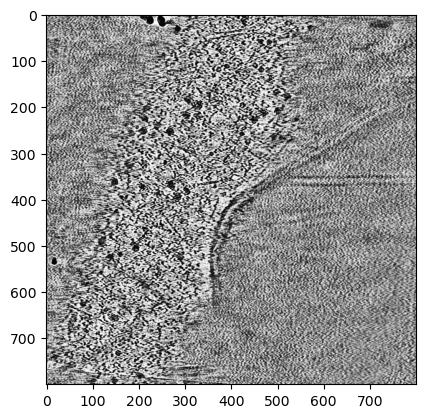

In [20]:
dataset = data.MrcDataset(
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092018.pkl",
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl", 
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate.pkl",
    "/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl",
    norm="hist",
    reshape=800,
    # map_class={"ribosome":0 },
    gap=1,
    length_for_average=3,
    transform=data.getConstantTransform(),
    add_classname=True,
    filtermin=0
)
t = dataset.__getitem__(pos=250)
plt.imshow(t["pixel_values"][1].numpy(), cmap="gray")

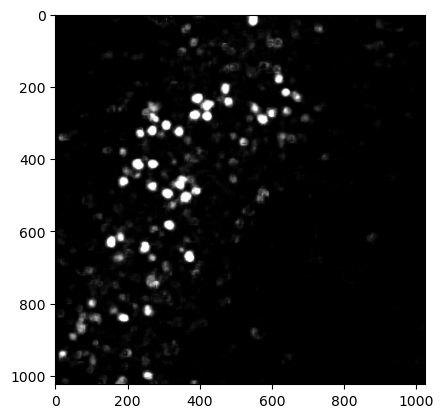

In [15]:
predict_mrc=utils.readTomogram("/data/transformer_project/transforemer_model/train_data/training/deepict/ribosome_fold2_out/predictions/ribosome_model_fold2/24092002/ribosome/probability_map.mrc")
plt.imshow(predict_mrc[250], cmap="gray")

In [30]:
df.to_csv("/home/feity/cryoem/temp/hsp60/24092001_ori/df.csv")

In [31]:
score, predict_center, ids = postprocess.getPredictionCenters(df, "hsp60", image_size=1024)
minz = np.min(labels[:, 0])
maxz = np.max(labels[:, 0])
print(minz, maxz)
for i, pos in zip(ids, predict_center):
    # print(pos)
    z = int(pos[0])
    if z < minz-10 or z > maxz+10:
        continue
    img = dataset.__getitem__(pos=int(pos[0]))["pixel_values"]
    # plt.imshow(img[1], cmap="gray")
    # plt.show()
    # plt.close()
    plt.imshow(img[1], cmap="gray")
    plt.scatter(pos[2]/1024*800, pos[1]/1024*800, s=100, edgecolors="r", facecolors="none")
    plt.savefig("/home/feity/cryoem/temp/hsp60/24092001_ori/%d.jpg"%i)
    plt.close()
    # plt.show()
    # break

70.9876339653751 448.00700164744643


In [16]:
centers = np.loadtxt("/data/transformer_project/transforemer_model/test_data/dxd20240920/ground_truth/24092023.txt")
centers[:, [0, 1, 2]] = centers[:, [2, 1, 0]]
centers[:, 1] = centers[:, 1] #/ 1024 * 800
centers[:, 2] = centers[:, 2] #/ 1024 * 800
centers.shape

(797, 3)

In [ ]:
need = ["24092001", "24092002", "24092018", "24092024", "24092028", "24092031"]
with open("/home/feity/cryoem/temp/results/ribo_24092001_gap1.pkl", "rb") as f:
    res = pickle.load(f) 
with open("/home/feity/cryoem/temp/ribo_centers_new.pkl", "rb") as f:
    ribo_centers = pickle.load(f)
centers = ribo_centers["24092001"]
df = res["df"]
graph = res["graph"]

In [92]:
import postprocess
importlib.reload(postprocess)

df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1
# df["largest"].value_counts()

# sllt0039
# important parameters for postprocessing
# min_samples and dis_penalty_cutoff
# if the size of the object changes throughout the tomogram, increase eps 
# if the object is small, add a little bit to enlarge the bounding box 

params= {
    "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "nucleus":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "ribo":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5}}, 
    "hsp60":{"min_prob":0.6, "nms":0.2, "max_area":0.03*0.03, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 3, "enlarge": 0.03}}, 
}

mark_and_filter = {
    "nucleus":{"max_cnt":1, "remove_iou": 0.4, "min_samples":20}, 
    "mitochondria":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
    "endoplasmic_reticulum_or_Golgi":{"max_cnt":20, "remove_iou": 0.8, "min_samples":20}, 
    "ribo":{"max_cnt":80000, "remove_iou": 0.5, "min_samples":12, "min_length":16, "extend":0, "max_samples":30}, 
    "hsp60":{"max_cnt":5000, "remove_iou": 0.5, "min_samples":5, "min_length":10, "extend":0, "max_samples":30},
}
# call object detection,  
# object from larger to smaller is recommended
# for i in ["nucleus", "mitochondria", "endoplasmic_reticulum_or_Golgi", "ribo"]:
# df = df[df["z"] > 260]
# for i in ["hsp60"]:
# print("hello")

params = {
    "endoplasmic_reticulum_or_Golgi": {
        "min_prob": 0.5,
        "nms": 0.6,
        "dbscan_prams": {
            "min_samples": 20,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "mitochondria": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "nucleus": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "ribo": {
        "min_prob": 0.35,
        "nms": 0.2,
        "max_area":0.05*0.05, 
        "dbscan_prams": {
            "min_samples": 6,
            "eps": 0.5,
            "cutoff": 5,
        },
    },
    "hsp60": {
        "min_prob": 0.5,
        "nms": 0.2,
        "max_area": 0.03 * 0.03,
        "dbscan_prams": {
            "min_samples": 4,
            "eps": 0.5,
            "dis_penalty_coef": 2.0 * (1 / 500),
            "dis_penalty_cutoff": 3,
            "enlarge": 0.03,
        },
    },
}

mark_and_filter = {
    "nucleus": {"max_cnt": 1, "remove_iou": 0.4, "min_samples": 20},
    "mitochondria": {"max_cnt": 10, "remove_iou": 0.6, "min_samples": 20},
    "endoplasmic_reticulum_or_Golgi": {
        "max_cnt": 20,
        "remove_iou": 0.8,
        "min_samples": 20,
    },
    "ribo": {
        "max_cnt": 80000,
        "remove_iou": 0.5,
        "min_samples": 12,
        "min_length": 16,
        "extend": 0,
        "max_samples": 30,
    },
    "hsp60": {
        "max_cnt": 5000,
        "remove_iou": 0.5,
        "min_samples": 5,
        "min_length": 10,
        "extend": 0,
        "max_samples": 30,
    },
}

# for i in ["ribo"]:
#     subdf = postprocess.processClass(df, i, **params[i], use_myscan=False)
#     # print(subdf.head())
#     postprocess.markFilter(df, i, subdf, **mark_and_filter[i])



In [4]:
import pickle
import postprocess
ribo_centers = {}
all_mrc = {
    
"24092002":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl",
"24092013":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092013_ribo.pkl",
"24092016":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092016_ribo.pkl",
"24092020":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092020_ribo.pkl",
"24092024":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092024_ribo.pkl",
"24092026":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092026_ribo.pkl",
"24092030":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092030_ribo.pkl",
"24092009":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092009_ribo.pkl",
"24092014":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092014_ribo.pkl",
"24092017":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092017_ribo.pkl",
"24092023":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092023_ribo.pkl",
"24092025":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092025_ribo.pkl",
"24092029":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092029_ribo.pkl",
"24092031":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092031_ribo.pkl"
}
dfs = [] 
cnt = 0
for name in all_mrc:
    print(name, cnt)
    cnt += 1
    # fist continue
    # continue
    with open(f"/home/feity/cryoem/temp/results/ribo_%s_gap1.pkl" % name, "rb") as f:
        res = pickle.load(f) 
    with open("/home/feity/cryoem/temp/ribo_centers_new.pkl", "rb") as f:
        ribo_centers = pickle.load(f)
    # second continue
    # continue
    centers = ribo_centers[name]
    df = res["df"]
    # subdf = postprocess.processClass(df, "ribo", **params["ribo"], use_myscan=False)
    # postprocess.markFilter(df, "ribo", subdf, **mark_and_filter["ribo"])
    score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
    
    idx = np.argsort(-score)
    score = score[idx]
    predict_center = predict_center[idx] 
    # predict_center = np.array(list(res["centers"].values()))
    # predict_center *= np.array((1, 1024/800, 1024/800))
    # predict_center = predict_center[:, [0, 2, 1]]
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, centers)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
    
    print(name, t)
    print("final score:", t["aupr2"]*t["cnts"]/len(centers))

    matches = np.array(matches)
    matched = matches[match_dists < 20] 
    matched = matched[:, 1]
    need = [] 
    for i in range(predict_center.shape[0]):
        if i not in matched:
            need.append(i) 
    k = ["label"] * len(centers) + ["additional_predicted"] * len(need)
    
    values = np.concatenate([centers, predict_center[need]], axis=0)
    df = pd.DataFrame(values, columns=["z", "y", "x"])
    df["label"] = k
    df["tomogram"] = name
    print("finish", name, cnt) 
    print(values.shape, predict_center.shape, centers.shape, t["cnts"], predict_center.shape[0] + centers.shape[0] - values.shape[0])
    dfs.append(df)
df = pd.concat(dfs, axis=0, ignore_index=True)
cnt

24092002 0
24092002 {'auroc': 0.7993897135360968, 'aupr': 0.8204197771069923, 'aupr2': 0.820967675247511, 'cnts': 291}
final score: 0.6157257564356333
finish 24092002 1
(629, 3) (532, 3) (388, 3) 291 291
24092013 1
24092013 {'auroc': 0.6308960249258757, 'aupr': 0.6946166750765261, 'aupr2': 0.6951240380070394, 'cnts': 737}
final score: 0.3525852828707419
finish 24092013 2
(1993, 3) (1277, 3) (1453, 3) 737 737
24092016 2
24092016 {'auroc': 0.6996300525891521, 'aupr': 0.7753945013634794, 'aupr2': 0.7760429310099947, 'cnts': 872}
final score: 0.52134779340579
finish 24092016 3
(1776, 3) (1350, 3) (1298, 3) 872 872
24092020 3
24092020 {'auroc': 0.7296864349011588, 'aupr': 0.8832054083770218, 'aupr2': 0.8841641873500601, 'cnts': 326}
final score: 0.6017484865889762
finish 24092020 4
(569, 3) (416, 3) (479, 3) 326 326
24092024 4
24092024 {'auroc': 0.7970202258413561, 'aupr': 0.8748967314724911, 'aupr2': 0.8754939132108404, 'cnts': 271}
final score: 0.6817783059774073
finish 24092024 5
(481, 3

14

In [ ]:
ribo_centers = {}
all_mrc = {
    
"24092002":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl",
"24092013":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092013_ribo.pkl",
"24092016":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092016_ribo.pkl",
"24092020":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092020_ribo.pkl",
"24092024":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092024_ribo.pkl",
"24092026":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092026_ribo.pkl",
"24092030":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092030_ribo.pkl",
"24092009":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092009_ribo.pkl",
"24092014":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092014_ribo.pkl",
"24092017":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092017_ribo.pkl",
"24092023":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092023_ribo.pkl",
"24092025":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092025_ribo.pkl",
"24092029":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092029_ribo.pkl",
"24092031":"/data/transformer_project/transforemer_model/train_data/training/newdata/24092031_ribo.pkl"
}
dfs = [] 
cnt = 0
for name in all_mrc:
    print(name, cnt)
    cnt += 1
    # fist continue
    # continue
    with open(f"/home/feity/cryoem/temp/results/ribo_%s_gap1.pkl" % name, "rb") as f:
        res = pickle.load(f) 
    with open("/home/feity/cryoem/temp/ribo_centers_new.pkl", "rb") as f:
        ribo_centers = pickle.load(f)
    # second continue
    # continue
    centers = ribo_centers[name]
    df = res["df"]
    
    
    
    score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
    
    idx = np.argsort(-score)
    score = score[idx]
    predict_center = predict_center[idx] 
    # predict_center = np.array(list(res["centers"].values()))
    # predict_center *= np.array((1, 1024/800, 1024/800))
    # predict_center = predict_center[:, [0, 2, 1]]
    matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, centers)
    t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
    print(name, t)
    matches = np.array(matches)
    matched = matches[match_dists < 20] 
    matched = matched[:, 1]
    need = [] 
    for i in range(predict_center.shape[0]):
        if i not in matched:
            need.append(i) 
    k = ["label"] * len(centers) + ["additional_predicted"] * len(need)
    
    values = np.concatenate([centers, predict_center[need]], axis=0)
    df = pd.DataFrame(values, columns=["z", "y", "x"])
    df["label"] = k
    df["tomogram"] = name
    print("finish", name, cnt) 
    print(values.shape, predict_center.shape, centers.shape, t["cnts"], predict_center.shape[0] + centers.shape[0] - values.shape[0])
    dfs.append(df)
df = pd.concat(dfs, axis=0, ignore_index=True)
cnt

In [67]:
df.to_csv("/home/feity/cryoem/temp/ribo_final_results.csv", index=False)

In [ ]:
postprocess.match_and_find_closest(predict_center, centers)

array([[ 28.87636465, 530.58057292,  49.67061678],
       [ 31.48656967, 153.81757135,  92.13355717],
       [ 38.30065359, 438.28963585, 116.3968254 ],
       ...,
       [204.5       , 129.13318062, 470.94882456],
       [284.5       , 427.26044973, 891.02557373],
       [142.5       , 156.0810496 , 375.52710215]])

In [9]:
# compare centers using df
df = res["df"]
# importlib.reload(postprocess)
score, predict_center, ids = postprocess.getPredictionCenters(df, "hsp60", image_size=1024)
idx = np.argsort(-score)
# idx = idx[:400]
score = score[idx]
predict_center = predict_center[idx]

# predict_center = np.array(list(res["centers"].values()))
# predict_center *= np.array([1, 1024/800, 1024/800])
# use the top X 
# idx = idx[:500]

matches, match_dists, closest =   postprocess.match_and_find_closest(predict_center, centers)
t = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
# roc, cnt, cnt/len(centers), cnt/len(idx), len(score), len(centers)
t, len(idx)

({'auroc': 0.757528383218991,
  'aupr': 0.5788248059719243,
  'aupr2': 0.5819681325712884,
  'cnts': 182},
 544)

In [68]:
with open( "/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl","rb") as f:
    p = pickle.load(f)
p.keys()

dict_keys(['annotations', 'masks', 'bboxes', 'mapclass', 'mrc_shape', 'mrc_path'])

In [56]:
predict_center

array(dict_values([array([ 26.57475995, 137.40946502,  52.09327846]), array([30.88441145, 18.4019088 , 99.66065748]), array([ 39.60662983, 258.94364641,  50.79226519]), array([ 37.44101773, 182.18658443,  85.69853508]), array([ 42.93061674, 206.280837  ,  79.66740088]), array([ 33.0236305 , 200.43823845,  59.52416756]), array([ 41.98982706, 199.02136317, 108.11597152]), array([ 50.0555962 , 454.3847842 ,  40.49085589]), array([ 52.88257576, 179.7790404 ,  61.67929293]), array([ 50.8716094 , 166.7124774 ,  91.58951175]), array([ 51.37433628, 555.63539823,  69.99823009]), array([ 69.19125683, 484.14754098,  25.17827869]), array([ 53.49064449, 538.1018711 ,  57.74636175]), array([ 53.54090909, 593.79659091,  60.35568182]), array([ 73.09461009, 176.0315367 , 111.5412844 ]), array([ 53.79895561, 638.50391645,  32.154047  ]), array([ 57.97643798, 202.14275814,  76.87456687]), array([ 64.52281746, 129.67113095, 151.08878968]), array([ 62.30622304, 235.14910659, 138.82008626]), array([ 68.0082

In [18]:
# compare centers using mask center 
predicted_center = list(res["centers"].values())
predicted_center = np.array(predicted_center)

# need the idx from above
predicted_center = predicted_center[idx]

predicted_center[:, 1] = predicted_center[:, 1] * 1024 / 800 
predicted_center[:, 2] = predicted_center[:, 2] * 1024 / 800 
matches, match_dists, closest = postprocess.match_and_find_closest(predicted_center, centers)
roc, cnt = postprocess.calculate_metrics(matches, match_dists, score, threshold=20)
roc, cnt, cnt/len(centers), cnt/len(idx), len(score), len(centers)


(0.5322921399363926, 155, 0.1944792973651192, 0.12006196746707978, 1291, 797)